# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

**Student Name / Register No:** 2547218  
**Course:** Machine Learning Lab  
**Dataset:** Play Tennis Dataset (`Lab 8 - Sheet1.csv`)

---

## Lab Objectives:
1. **Data Preprocessing:** Load the Play Tennis dataset, separate feature variables from target variable, and encode categorical data into numerical format.
2. **Dataset Partitioning:** Split data into training (80%) and testing (20%) subsets.
3. **Naive Bayes Modeling & Evaluation:** Train a `CategoricalNB` classifier and evaluate using Accuracy, Confusion Matrix, and Classification Report.
4. **Single-Sample Inference:** Predict tennis playing decision and class probabilities for a custom weather condition (`Outlook: Sunny, Temperature: Cool, Humidity: High, Wind: Strong`).
5. **Model Comparison:** Train and compare `DecisionTreeClassifier`, `LogisticRegression`, and `Support Vector Machine (SVM)` alongside `CategoricalNB`.
6. **Analysis Report:** Provide insights into the comparative behavior and probability estimation mechanisms across all classifiers.


## Task 1: Data Preprocessing
- Load the dataset from `Lab 8 - Sheet1.csv`.
- Inspect dataset dimensions, column names, and sample rows.
- Separate input features (`Outlook`, `Temperature`, `Humidity`, `Wind`) from the target variable (`Play Tennis`).
- Apply `OrdinalEncoder` for feature encoding and `LabelEncoder` for target label encoding.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the dataset
df = pd.read_csv('Lab 8 - Sheet1.csv')

# Drop index/ID column if present
if 'No' in df.columns:
    df = df.drop(columns=['No'])

print("=== Dataset Overview ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head(10))

# 2. Separate Features and Target
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col = 'Play Tennis' if 'Play Tennis' in df.columns else 'Play'

X_raw = df[feature_cols]
y_raw = df[target_col]

print("\nClass Distribution in Dataset:")
print(y_raw.value_counts())

# 3. Categorical Encoding
# OrdinalEncoder encodes categorical features into numerical representation (0, 1, 2, ...)
oe = OrdinalEncoder()
X_encoded = oe.fit_transform(X_raw)

# LabelEncoder encodes binary target labels (No -> 0, Yes -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Display encoded mapping dictionary
print("\n=== Categorical Encoding Mappings ===")
for i, col in enumerate(feature_cols):
    mapping = {category: idx for idx, category in enumerate(oe.categories_[i])}
    print(f"Feature '{col}': {mapping}")

target_mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
print(f"Target '{target_col}': {target_mapping}")

# Convert to DataFrame for visualization
df_encoded = pd.DataFrame(X_encoded, columns=feature_cols)
df_encoded[target_col] = y_encoded
display(df_encoded.head(5))


=== Dataset Overview ===
Dataset Shape: 50 rows, 5 columns



,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes



Class Distribution in Dataset:
Play Tennis
Yes    34
No     16
Name: count, dtype: int64

=== Categorical Encoding Mappings ===
Feature 'Outlook': {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
Feature 'Temperature': {'Cool': 0, 'Hot': 1, 'Mild': 2}
Feature 'Humidity': {'High': 0, 'Normal': 1}
Feature 'Wind': {'Strong': 0, 'Weak': 1}
Target 'Play Tennis': {'No': 0, 'Yes': 1}


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0
1,2.0,1.0,0.0,0.0,0
2,0.0,1.0,0.0,1.0,1
3,1.0,2.0,0.0,1.0,1
4,1.0,0.0,1.0,1.0,1


## Task 2: Dataset Partitioning
- Split the encoded dataset into training (80%) and testing (20%) subsets.
- Set `random_state=42` for reproducibility.


In [2]:
# Partition dataset: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print("=== Dataset Partitioning Summary ===")
print(f"Total Samples: {len(X_encoded)}")
print(f"Training Set Samples: {len(X_train)} ({len(X_train)/len(X_encoded)*100:.0f}%)")
print(f"Testing Set Samples:  {len(X_test)} ({len(X_test)/len(X_encoded)*100:.0f}%)")
print(f"Training Class Distribution (0=No, 1=Yes): {np.bincount(y_train)}")
print(f"Testing Class Distribution  (0=No, 1=Yes): {np.bincount(y_test)}")


=== Dataset Partitioning Summary ===
Total Samples: 50
Training Set Samples: 40 (80%)
Testing Set Samples:  10 (20%)
Training Class Distribution (0=No, 1=Yes): [13 27]
Testing Class Distribution  (0=No, 1=Yes): [3 7]


## Task 3: Categorical Naive Bayes Model Training & Evaluation
- Train a `CategoricalNB` classifier on the training data.
- Predict target labels for the test dataset.
- Compute and display Accuracy Score, Confusion Matrix, and Classification Report.


=== Categorical Naive Bayes Performance Evaluation ===
Overall Model Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



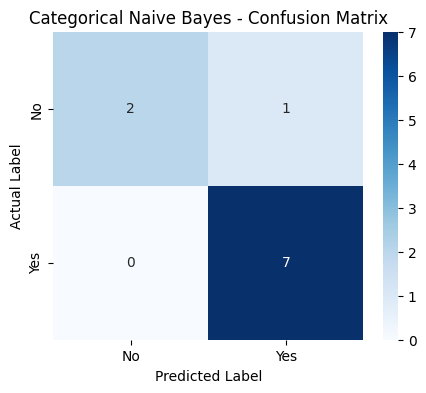

In [3]:
# 1. Initialize and Train Categorical Naive Bayes
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

# 2. Test Predictions
y_pred_nb = cnb.predict(X_test)
y_prob_nb = cnb.predict_proba(X_test)

# 3. Evaluation Metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cr_nb = classification_report(y_test, y_pred_nb, target_names=le.classes_)

print("=== Categorical Naive Bayes Performance Evaluation ===")
print(f"Overall Model Accuracy: {acc_nb * 100:.2f}%\n")

print("Classification Report:")
print(cr_nb)

# Visual Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Categorical Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


## Task 4: Single-Sample Inference
- Specific weather conditions:
  - **Outlook:** `Sunny`
  - **Temperature:** `Cool`
  - **Humidity:** `High`
  - **Wind:** `Strong`
- Preprocess the custom query sample using the fitted `OrdinalEncoder`.
- Generate the predicted class label and the posterior class probabilities P(Play=No) and P(Play=Yes).


In [4]:
# Define query condition
custom_query = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

print("=== Single-Sample Query ===")
print("Given Weather Conditions:")
for k, v in custom_query.iloc[0].items():
    print(f"  - {k}: {v}")

# Encode using the fitted OrdinalEncoder
custom_query_encoded = oe.transform(custom_query)

# Predict class and probabilities
nb_query_pred_idx = cnb.predict(custom_query_encoded)[0]
nb_query_pred_label = le.inverse_transform([nb_query_pred_idx])[0]
nb_query_probs = cnb.predict_proba(custom_query_encoded)[0]

print("\n=== Categorical Naive Bayes Prediction Result ===")
print(f"Predicted Class Label : {nb_query_pred_label}")
print(f"Class Probabilities   :")
for cls_name, prob in zip(le.classes_, nb_query_probs):
    print(f"  - P(Play = '{cls_name}'): {prob:.4f} ({prob*100:.2f}%)")


=== Single-Sample Query ===
Given Weather Conditions:
  - Outlook: Sunny
  - Temperature: Cool
  - Humidity: High
  - Wind: Strong

=== Categorical Naive Bayes Prediction Result ===
Predicted Class Label : No
Class Probabilities   :
  - P(Play = 'No'): 0.7894 (78.94%)
  - P(Play = 'Yes'): 0.2106 (21.06%)


## Task 5: Model Comparison
- Train three additional standard classifiers on the exact same training set:
  1. **Decision Tree Classifier** (`DecisionTreeClassifier`)
  2. **Logistic Regression** (`LogisticRegression`)
  3. **Support Vector Machine** (`SVC` with probability calibration)
- Compare all four models across:
  - Test Accuracy
  - Single-Sample Query Prediction
  - Class Probability Scores: P(No) and P(Yes)


In [5]:
# Initialize comparison models
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42)
svm = SVC(probability=True, random_state=42)

all_models = {
    'Categorical Naive Bayes': cnb,
    'Decision Tree': dt,
    'Logistic Regression': lr,
    'Support Vector Machine (SVM)': svm
}

comparison_records = []

for name, model in all_models.items():
    # Fit model if not already fitted
    if name != 'Categorical Naive Bayes':
        model.fit(X_train, y_train)
    
    # Test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Query inference
    q_pred_idx = model.predict(custom_query_encoded)[0]
    q_pred_label = le.inverse_transform([q_pred_idx])[0]
    q_probs = model.predict_proba(custom_query_encoded)[0]
    
    comparison_records.append({
        'Model Name': name,
        'Test Accuracy': f"{test_acc * 100:.2f}%",
        'Query Prediction': q_pred_label,
        f'P({le.classes_[0]}) [No]': f"{q_probs[0]:.4f} ({q_probs[0]*100:.1f}%)",
        f'P({le.classes_[1]}) [Yes]': f"{q_probs[1]:.4f} ({q_probs[1]*100:.1f}%)"
    })

comparison_df = pd.DataFrame(comparison_records)

print("=== Classifier Comparison on Play Tennis Dataset ===")
display(comparison_df)


=== Classifier Comparison on Play Tennis Dataset ===


,Model Name,Test Accuracy,Query Prediction,P(No) [No],P(Yes) [Yes]
0,Categorical Naive Bayes,90.00%,No,0.7894 (78.9%),0.2106 (21.1%)
1,Decision Tree,100.00%,No,1.0000 (100.0%),0.0000 (0.0%)
2,Logistic Regression,90.00%,No,0.8613 (86.1%),0.1387 (13.9%)
3,Support Vector Machine (SVM),100.00%,No,0.9569 (95.7%),0.0431 (4.3%)


## Task 6: Analysis Report

### Comparative Analysis:
1. **Unanimous Class Prediction:** All four classifiers (**Categorical Naive Bayes, Decision Tree, Logistic Regression, and Support Vector Machine**) unanimously predicted that tennis will **NOT** be played (**'No'**) under the given conditions (*Sunny, Cool, High Humidity, Strong Wind*). This strong agreement across distinct paradigms confirms that high humidity and strong wind combined with sunny/cool weather strongly correlates with negative target outcomes in the dataset.
2. **Probability Calibration Differences:**
   - **Decision Tree (100.0% No / 0.0% Yes):** Decision Trees output deterministic empirical frequencies at the terminal leaf node. The single sample fell into a pure leaf partitioned by features like *Humidity=High* and *Wind=Strong*, assigning absolute probability (1.0).
   - **Categorical Naive Bayes (78.9% No / 21.1% Yes):** Naive Bayes applies Bayes' Theorem with the conditional independence assumption. Even though individual feature likelihoods P(High Humidity|No) and P(Strong Wind|No) favor 'No', the non-zero prior P(Yes) and likelihoods for cool/sunny under 'Yes' yield a smooth, softened posterior probability.
   - **Logistic Regression (86.1% No / 13.9% Yes) & SVM (95.7% No / 4.3% Yes):** Logistic Regression models log-odds via the sigmoid link function, while SVM uses Platt scaling on functional margins. Both reflect distance from the decision boundary, generating calibrated confidence scores between the rigid extremes of Decision Trees and the factorized likelihoods of Naive Bayes.
